In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/ahmendabad_house_price.csv')

## 1.Data Understanding

In [3]:
df.head()

,name,location,description,rate_per_sqft,area_in_sqft,area_type,property_title,property_type,bhk_type,price_in_cr
0,swarnim sentossa,swarnim sentossa,let your dream of owning a flat come true with...,5009.0,2250.0,super,swarnim sentossa,flat,3,NaN
1,scarlet springs,scarlet springs,"scarlet springs is a residential project, offe...",4377.0,1674.0,super,scarlet springs,flat,3,0.7328
2,suryansh sanidhya shivalaya,"sarkhej, sarkhej okaf, ahmedabad",suryansh sanidhya shivalaya society now offers...,3931.0,1080.0,super,suryansh sanidhya shivalaya,flat,2,0.4245
3,siddhi terrace skyline,memnagar,"siddhi terrace skyline, one of the known housi...",7198.0,2320.0,super,siddhi terrace skyline,flat,3,1.6700
4,aadhya arambh,"ghatlodia, ahmedabad","beautiful 3,4 bhk apartments in ghatlodia, are...",NaN,1604.0,carpet,aadhya arambh,flat,4,NaN


In [4]:
df.shape

(20060, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20060 entries, 0 to 20059
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            19950 non-null  object 
 1   location        19765 non-null  object 
 2   description     20045 non-null  object 
 3   rate_per_sqft   19701 non-null  float64
 4   area_in_sqft    20036 non-null  float64
 5   area_type       20060 non-null  object 
 6   property_title  19949 non-null  object 
 7   property_type   20060 non-null  object 
 8   bhk_type        20060 non-null  int64  
 9   price_in_cr     19332 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 1.5+ MB


In [6]:
df.describe()

,rate_per_sqft,area_in_sqft,bhk_type,price_in_cr
count,1.970100e+04,2.003600e+04,20060.000000,19332.000000
mean,1.375771e+04,3.123944e+03,2.903988,1.462586
std,2.134984e+05,7.027497e+04,1.207127,2.101026
min,0.000000e+00,1.000000e+00,1.000000,0.010000
25%,4.620000e+03,1.000000e+03,2.000000,0.550000
50%,6.153000e+03,1.500000e+03,3.000000,0.850000
75%,8.860000e+03,2.169000e+03,3.000000,1.550000
max,1.500000e+07,6.534000e+06,45.000000,120.000000


In [7]:
for i in df.columns:
  print(df[i].value_counts())
  print('='* 30)

name
godrej garden city             74
safal riviera aspire           71
savvy swaraaj sports living    58
godrej green glades            49
archway by adani realty        46
                               ..
hrishiraj h4                    1
sonnet opus                     1
antriksh complex                1
aaradhya apartment              1
adoor arise                     1
Name: count, Length: 7291, dtype: int64
location
science city, ahmedabad        88
godrej garden city             74
sola, ahmedabad                72
safal riviera aspire           59
savvy swaraaj sports living    55
                               ..
sentosa greenland               1
shreekar celestial living       1
shree ram residency             1
roseville                       1
on reqeust                      1
Name: count, Length: 7282, dtype: int64
description
a quiet and beautiful apartment located in heart of the city is available on sale in ahmedabad. property is nicely located with all facilities nea

## 2.Missing Value Handling

In [8]:
df.isnull().sum()

,0
name,110
location,295
description,15
rate_per_sqft,359
area_in_sqft,24
area_type,0
property_title,111
property_type,0
bhk_type,0
price_in_cr,728


In [9]:
df = df.drop(['location','description','name','property_title'],axis=1)

In [10]:
df.head()

,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
0,5009.0,2250.0,super,flat,3,NaN
1,4377.0,1674.0,super,flat,3,0.7328
2,3931.0,1080.0,super,flat,2,0.4245
3,7198.0,2320.0,super,flat,3,1.6700
4,NaN,1604.0,carpet,flat,4,NaN


In [11]:
def handling_missing_data(df):

    for i in df.columns:
        if df[i].dtype == 'object':
            df[i] = df[i].fillna(df[i].mode()[0])
        else:
            df[i] = df[i].fillna(df[i].median())
    return df

In [12]:
df = handling_missing_data(df)

In [13]:
df.head()

,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
0,5009.0,2250.0,super,flat,3,0.8500
1,4377.0,1674.0,super,flat,3,0.7328
2,3931.0,1080.0,super,flat,2,0.4245
3,7198.0,2320.0,super,flat,3,1.6700
4,6153.0,1604.0,carpet,flat,4,0.8500


In [14]:
df.isnull().sum()

,0
rate_per_sqft,0
area_in_sqft,0
area_type,0
property_type,0
bhk_type,0
price_in_cr,0


## 3.EDA

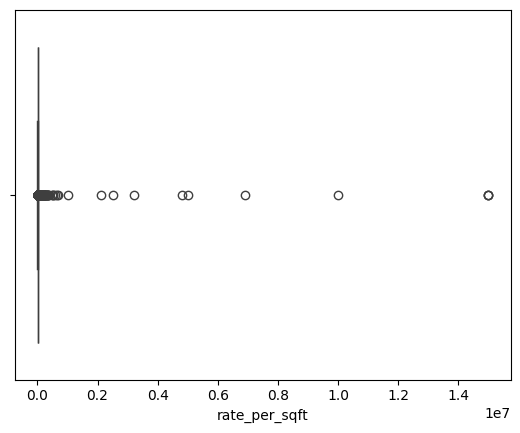

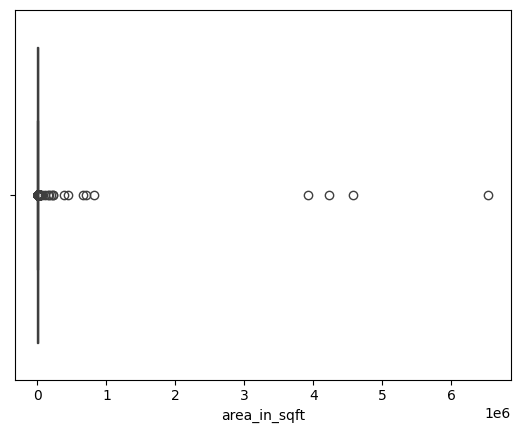

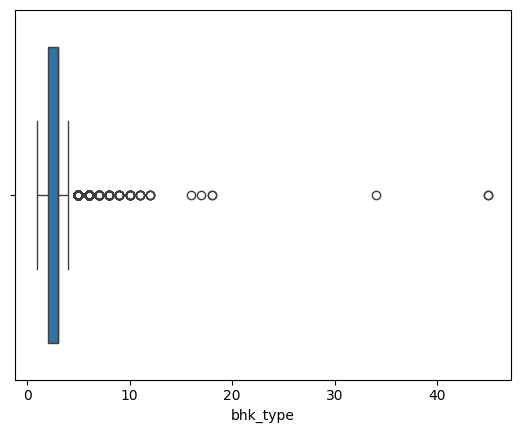

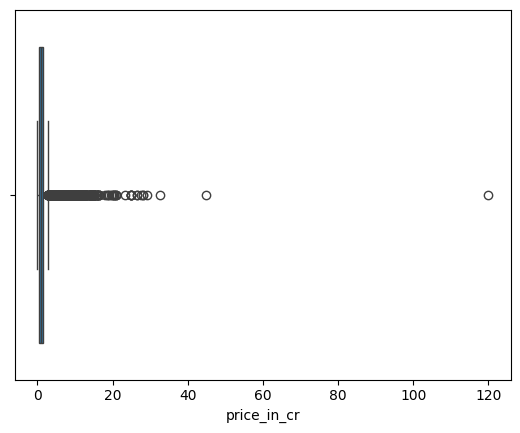

In [15]:
# Univariate Analysis

numeric_cols = ['rate_per_sqft','area_in_sqft','bhk_type','price_in_cr']

for i in numeric_cols:
    sns.boxplot(
        data=df,
        x=i

    )
    plt.xlabel(i)
    plt.show()

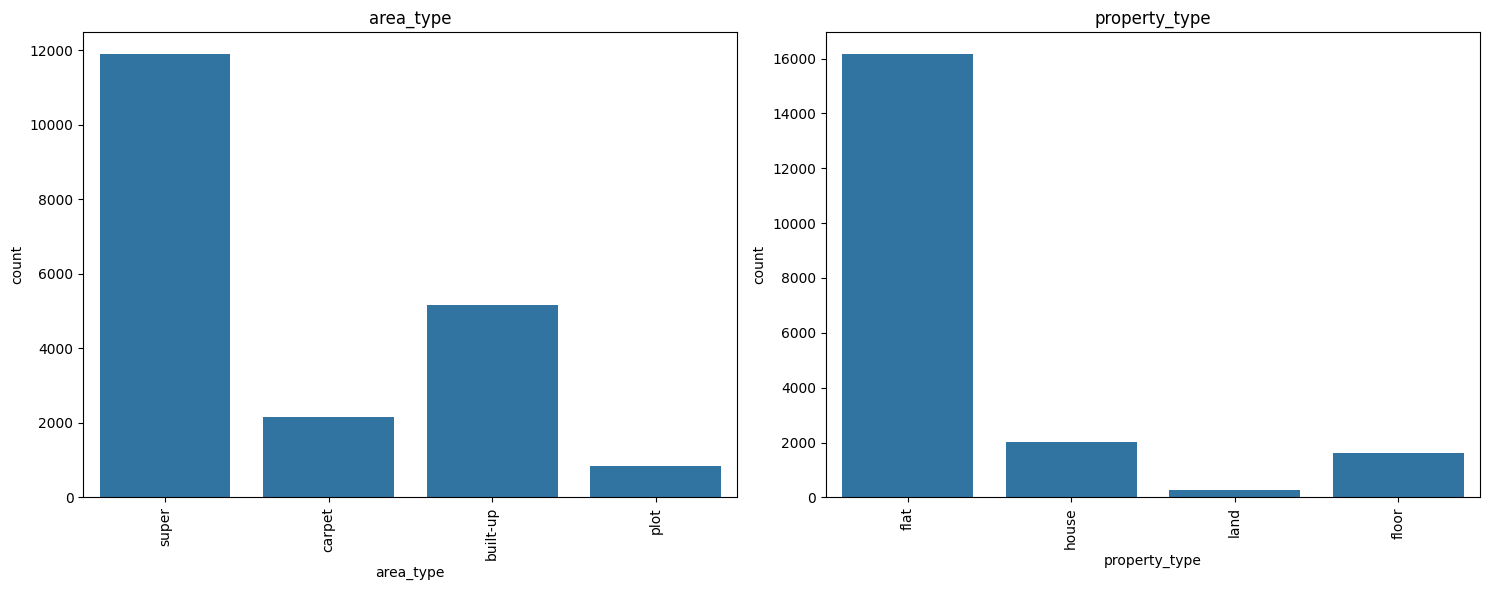

In [16]:
cat_cols = df.select_dtypes(include='object').columns

n = len(cat_cols)
cols = 2                     # Number of plots per row
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=90)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

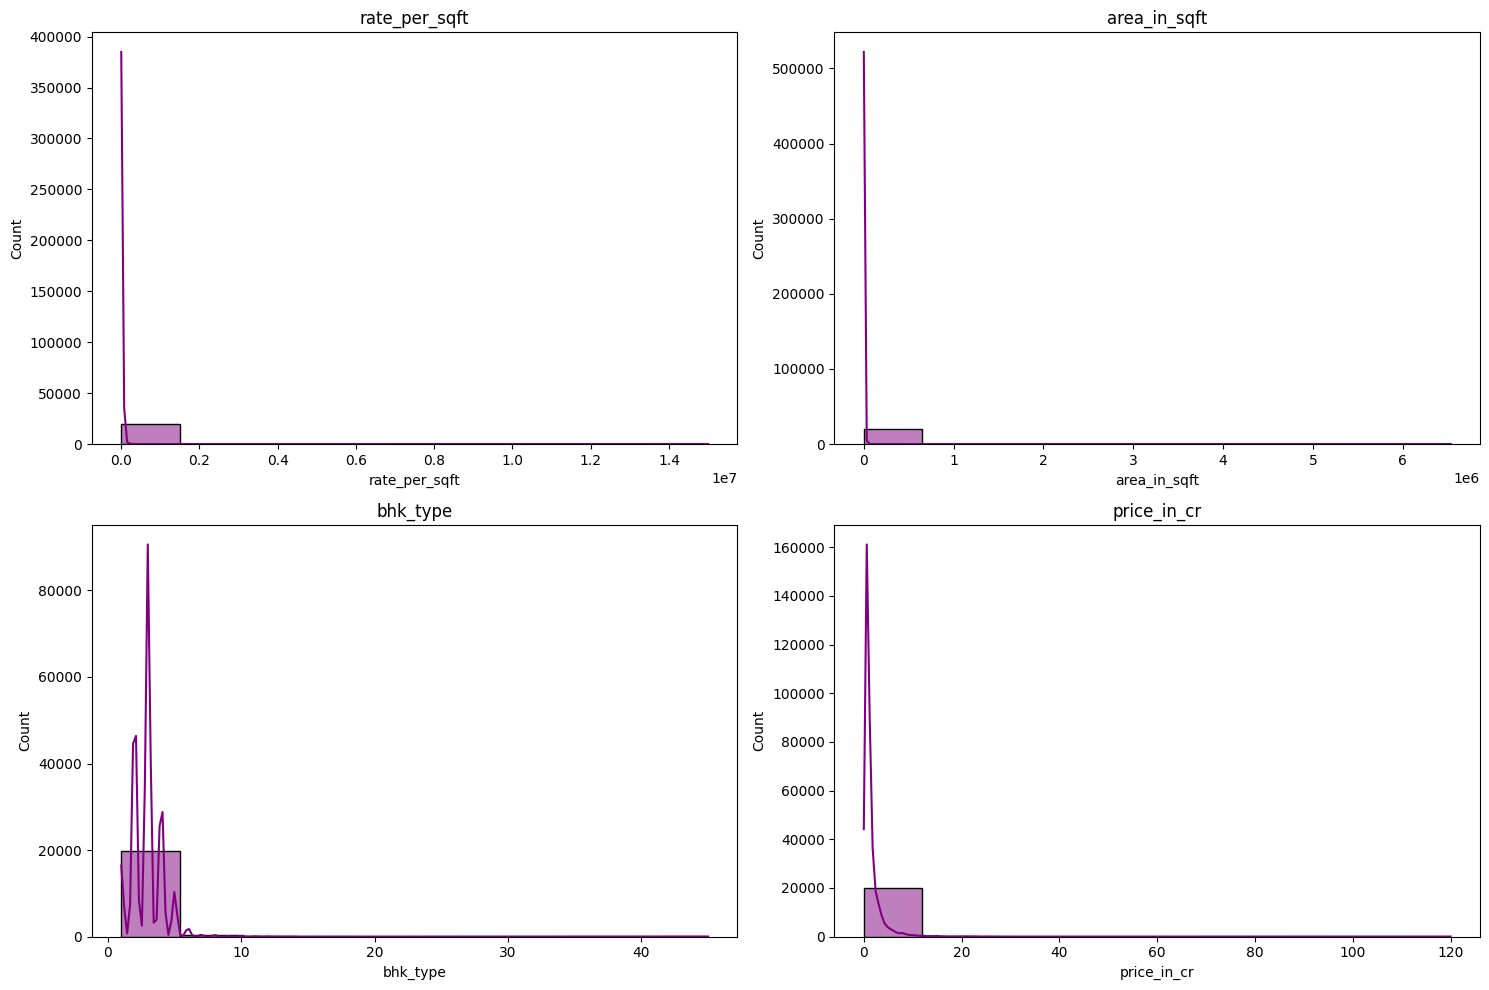

In [17]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(
    nrows=(len(num_cols)+1)//2,
    ncols=2,
    figsize=(15, 5*((len(num_cols)+1)//2))
)

axes = axes.flatten()

j = 0
for i in df.columns:
    if df[i].dtype in ['int64', 'float64']:
        sns.histplot(
            data=df,
            x=i,
            kde=True,
            ax=axes[j],
            bins = 10,
            color = 'purple'
        )
        axes[j].set_title(i)
        j += 1

# Remove empty subplots
for k in range(j, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.show()

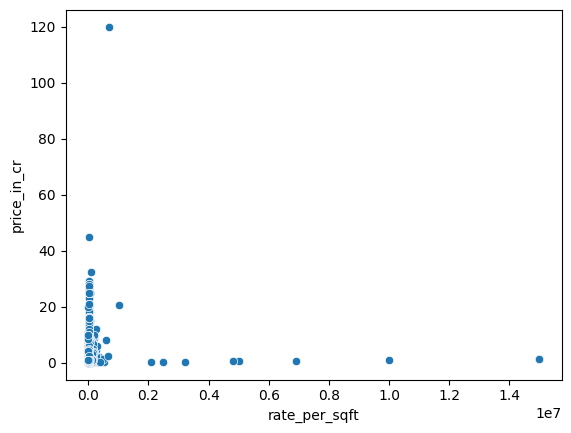

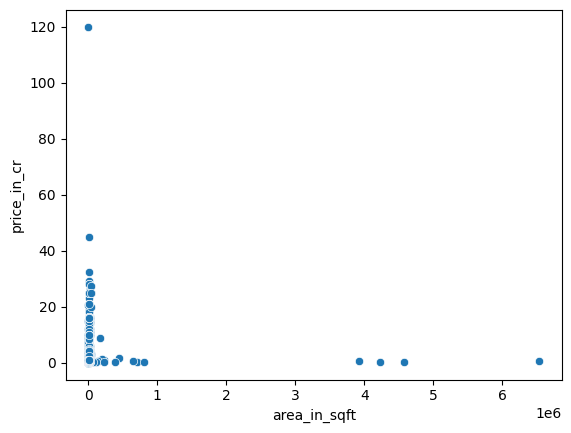

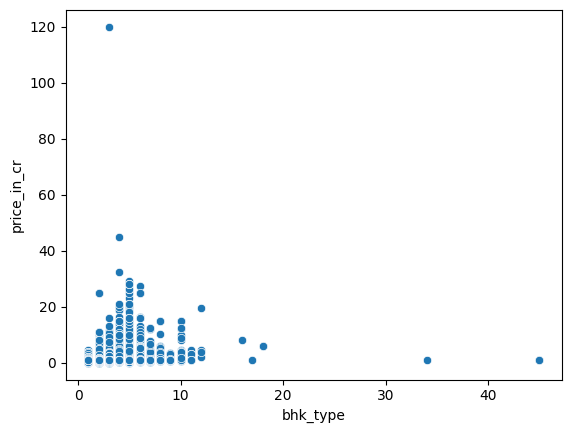

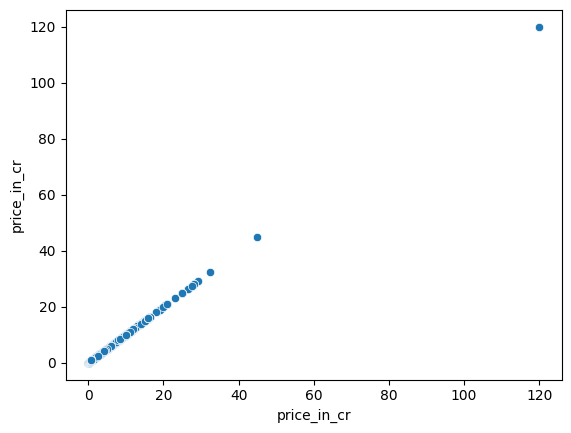

In [18]:
for i in numeric_cols:
    sns.scatterplot(
        data=df,
        x=i,
        y='price_in_cr'
    )
    plt.show()

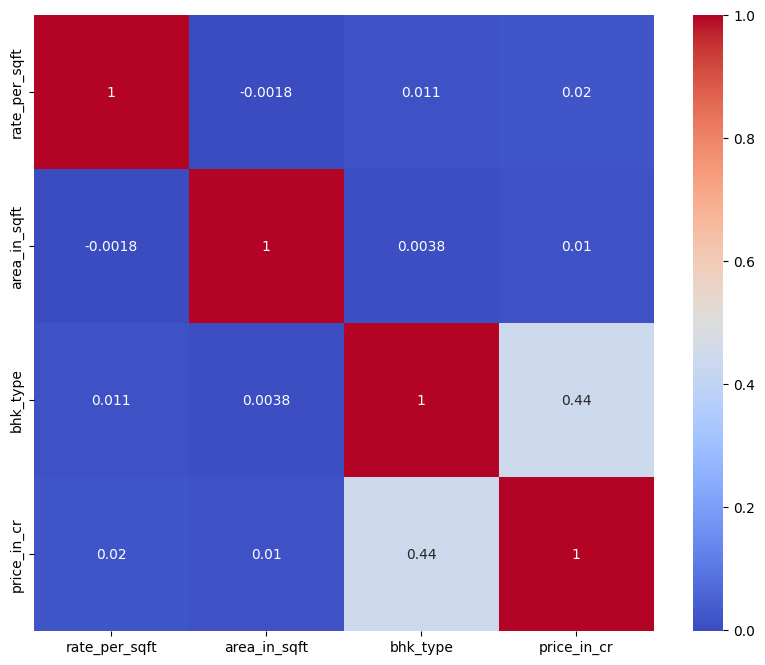

In [19]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [20]:
df.columns

Index(['rate_per_sqft', 'area_in_sqft', 'area_type', 'property_type',
       'bhk_type', 'price_in_cr'],
      dtype='object')

## 4.Handling Outliers

In [21]:
# Outlier Handling Using IQR Method

q1 = df['rate_per_sqft'].quantile(0.25)
q3 = df['rate_per_sqft'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q1 + 1.5 * iqr

outliers = df[(df['rate_per_sqft'] < lower) | (df['rate_per_sqft'] > upper)]

print(outliers.shape)

(3178, 6)


In [22]:
df.nlargest(10, 'rate_per_sqft')

,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
5931,15000000.0,1.0,built-up,floor,3,1.50
16557,15000000.0,1.0,super,flat,4,1.50
16566,15000000.0,1.0,plot,house,4,1.50
15708,10000000.0,1.0,super,flat,3,1.05
5369,6900000.0,1.0,built-up,floor,3,0.69
1258,5000000.0,1.0,built-up,flat,1,0.50
8405,4800000.0,1.0,super,flat,2,0.48
9368,3200000.0,1.0,super,flat,1,0.32
9803,2500000.0,1.0,plot,house,2,0.25
12420,2100000.0,1.0,plot,flat,1,0.21


In [23]:
df.shape

(20060, 6)

In [24]:
df['price_in_cr'].sort_values(ascending=False)

,price_in_cr
17583,120.0000
10675,45.0000
15171,32.5000
3350,29.3000
7461,28.0000
...,...
7994,0.0270
7964,0.0270
7672,0.0117
14733,0.0100


In [25]:
df['area_in_sqft'] = df['area_in_sqft'].clip(lower, upper)

In [26]:
# Very small properties
print(df[df['area_in_sqft'] <= 100].shape)

# Very large properties
print(df[df['area_in_sqft'] >= 10000].shape)

# Largest 20 properties
df.nlargest(20, 'area_in_sqft')

(293, 6)
(247, 6)


,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
73,1392.0,10852.625,super,flat,5,1.52
110,4130.0,10852.625,super,flat,6,4.58
340,7618.0,10852.625,super,flat,5,10.25
825,1.0,10852.625,super,flat,2,0.75
1250,253.0,10852.625,plot,land,10,1.10
1331,1000.0,10852.625,built-up,house,2,1.35
1712,1146.0,10852.625,super,flat,5,1.30
1827,556.0,10852.625,super,flat,4,1.20
1867,482.0,10852.625,super,flat,3,0.56
1885,541.0,10852.625,super,flat,2,0.50


## 5. Feature Enginnerinng

In [27]:
df.head()

,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
0,5009.0,2250.0,super,flat,3,0.8500
1,4377.0,1674.0,super,flat,3,0.7328
2,3931.0,1080.0,super,flat,2,0.4245
3,7198.0,2320.0,super,flat,3,1.6700
4,6153.0,1604.0,carpet,flat,4,0.8500


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['area_type'] = le.fit_transform(df['area_type'])
df['property_type'] = le.fit_transform(df['property_type'])

## 8. Train-Test Split

In [29]:
from sklearn.model_selection import train_test_split

X = df.drop('price_in_cr',axis=1)
y = df['price_in_cr']

In [30]:
X_train,X_test,y_train,y_test = train_test_split(
                                            X,
                                            y,
                                            test_size=0.2,
                                            random_state=42
                                          )

In [31]:
# Feature Scalling

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 9.Train Multiple Models

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error

In [33]:
algorithems = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'ExtraTreesRegressor': ExtraTreesRegressor(random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
    'AdaBoostRegressor': AdaBoostRegressor(random_state=42),
    'XGBRegressor': XGBRegressor(random_state=42),
    'SVR': SVR(),
    'KNeighborsRegressor': KNeighborsRegressor()
}

In [34]:
results = []

for name, model in algorithems.items():

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Store result
    results.append({
        'Model': name,
        'R2 Score': r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    })
# Create DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,R2 Score,MAE,MSE,RMSE
0,LinearRegression,0.491363,0.626726,2.243505,1.497833
1,Ridge,0.491356,0.626727,2.243533,1.497843
2,Lasso,0.146824,0.978960,3.763200,1.939897
3,ElasticNet,0.286593,0.840652,3.146706,1.773896
4,DecisionTreeRegressor,0.849088,0.157504,0.665646,0.815872
5,RandomForestRegressor,0.881330,0.145157,0.523431,0.723485
6,ExtraTreesRegressor,0.873322,0.134663,0.558755,0.747499
7,GradientBoostingRegressor,0.900572,0.197468,0.438559,0.662238
8,AdaBoostRegressor,0.081102,0.910213,4.053089,2.013229
9,XGBRegressor,0.872368,0.170773,0.562960,0.750307


In [35]:
# Sort by R2 Score
results_df = results_df.sort_values(by='R2 Score', ascending=False)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,R2 Score,MAE,MSE,RMSE
0,GradientBoostingRegressor,0.900572,0.197468,0.438559,0.662238
1,RandomForestRegressor,0.881330,0.145157,0.523431,0.723485
2,ExtraTreesRegressor,0.873322,0.134663,0.558755,0.747499
3,XGBRegressor,0.872368,0.170773,0.562960,0.750307
4,DecisionTreeRegressor,0.849088,0.157504,0.665646,0.815872
5,KNeighborsRegressor,0.634777,0.377944,1.610933,1.269225
6,SVR,0.551264,0.449501,1.979292,1.406873
7,LinearRegression,0.491363,0.626726,2.243505,1.497833
8,Ridge,0.491356,0.626727,2.243533,1.497843
9,ElasticNet,0.286593,0.840652,3.146706,1.773896


## 10.Model Tuning

In [36]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [37]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [38]:

GBR = GradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=GBR,
    param_distributions=param_dist,
    n_iter=30,          # Try only 30 combinations
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.1}
0.7664814566419001


In [39]:
# RandomForest
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [44]:
RF = RandomForestRegressor(random_state=42)

RF_grid = RandomizedSearchCV(
    estimator=RF,
    param_distributions=param_dist,
    n_iter=25,           # Number of random combinations
    scoring='r2',        # Evaluation metric
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

RF_grid.fit(X_train, y_train)

print("Best Estimator:")
print(RF_grid.best_estimator_)

print("\nBest Parameters:")
print(RF_grid.best_params_)

print("\nBest Cross Validation R2 Score:")
print(RF_grid.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Estimator:
RandomForestRegressor(max_depth=30, max_features='log2', n_estimators=200,
                      random_state=42)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}

Best Cross Validation R2 Score:
0.7695931526375122


In [42]:
# ExtraTree
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [45]:

Extra = ExtraTreesRegressor(random_state=42)

Extra_grid = RandomizedSearchCV(
    estimator=Extra,
    param_distributions=param_dist,
    n_iter=25,          # Try 25 random combinations
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

Extra_grid.fit(X_train, y_train)

print("Best Estimator:")
print(Extra_grid.best_estimator_)

print("\nBest Parameters:")
print(Extra_grid.best_params_)

print("\nBest CV R2 Score:")
print(Extra_grid.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Estimator:
ExtraTreesRegressor(max_features='sqrt', min_samples_split=5, n_estimators=300,
                    random_state=42)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Best CV R2 Score:
0.7733116732887148
